<a href="https://colab.research.google.com/github/Asritha0507/ML-Market-Basket-Analysis/blob/main/09_SHAP_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import os
import gc
import xgboost as xgb
import shap

base_path = "/content/drive/MyDrive/ML_Market_Basket_Analysis"
engineered_path = f"{base_path}/Datasets/Engineered_Features"
model_path = f"{base_path}/Models/Model_Outputs/xgboost_next_basket_ranker.json"
output_path = f"{base_path}/Models/Model_Outputs"

model = xgb.XGBRanker()
model.load_model(model_path)

print("XGBoost model loaded")
print("SHAP version:", shap.__version__)

Mounted at /content/drive
XGBoost model loaded
SHAP version: 0.52.0


In [ ]:
feature_cols = [
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "times_purchased_before",
    "first_purchase_before",
    "last_purchase_before",
    "recency_before",
    "purchase_span_before",
    "was_previously_purchased",
    "aisle_id",
    "department_id",
    "previous_orders",
    "avg_basket_before",
    "max_basket_before",
    "total_items_before",
    "order_progress"
]

files = sorted([
    os.path.join(engineered_path, f)
    for f in os.listdir(engineered_path)
    if f.endswith(".parquet")
])

sample = pd.read_parquet(
    files[-1],
    columns=feature_cols
).sample(n=5000, random_state=42)

X_sample = sample[feature_cols].astype(float)

print("Sample shape:", X_sample.shape)
print("Features:", len(feature_cols))
print("Missing values:", int(X_sample.isna().sum().sum()))

Sample shape: (5000, 17)
Features: 17
Missing values: 0


In [ ]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

print("SHAP calculation complete")
print("SHAP shape:", shap_values.shape)
print("Feature count:", len(feature_cols))

SHAP calculation complete
SHAP shape: (5000, 17)
Feature count: 17


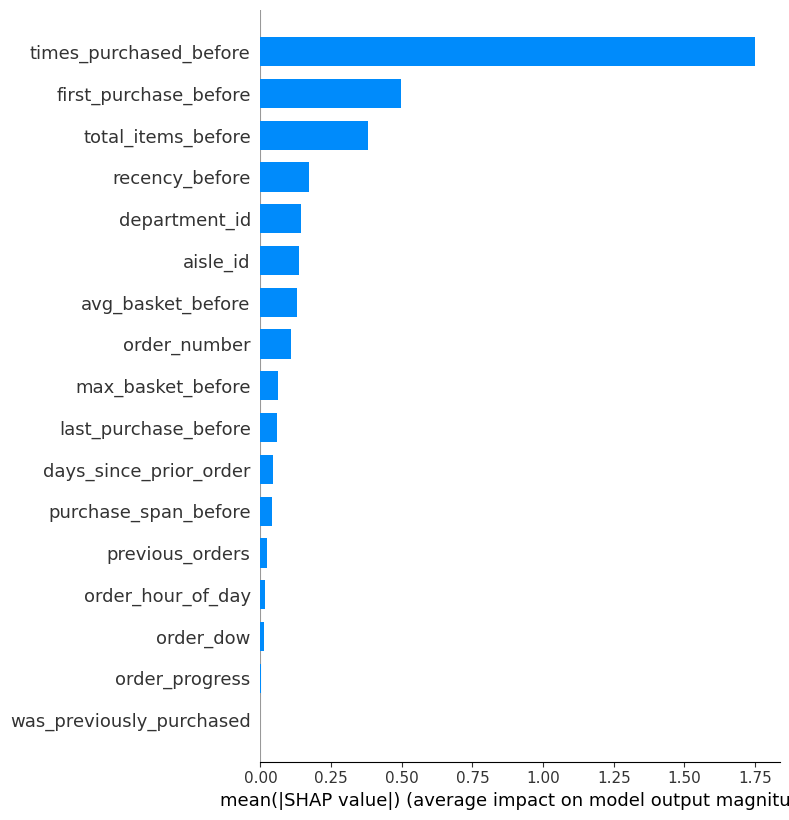

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

import matplotlib.pyplot as plt

plt.tight_layout()
plt.savefig(
    f"{output_path}/shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_absolute_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_absolute_shap", ascending=False)

shap_path = f"{output_path}/shap_feature_importance.csv"

shap_importance.to_csv(shap_path, index=False)

print("NOTEBOOK 9 COMPLETE")
print("Saved:", shap_path)
print("\nTop 10 SHAP features:")
print(shap_importance.head(10).to_string(index=False))

NOTEBOOK 9 COMPLETE
Saved: /content/drive/MyDrive/ML_Market_Basket_Analysis/04_Results/shap_feature_importance.csv

Top 10 SHAP features:
               feature  mean_absolute_shap
times_purchased_before            1.750547
 first_purchase_before            0.495548
    total_items_before            0.379886
        recency_before            0.172420
         department_id            0.143668
              aisle_id            0.135113
     avg_basket_before            0.130210
          order_number            0.106576
     max_basket_before            0.063626
  last_purchase_before            0.057164
